# Lab 3: Neural Networks: Feedforward Networks and the Training Process

**Duration:** 1 week [21 Jul - 28 Jul, 2026]
**Due Date:** 28th July, 2026
**Format:** Jupyter Notebook / Google Colab
**Grading:** This is a graded lab.

**Student Name:** Kojo Kootin-Sanwu
**Student ID:** 63952028

---

### Objective

This lab bridges the gap between classical ML and deep learning. Instead of calling
`.fit()` and trusting scikit-learn, you will **open the black box**: build a neural network
from a single neuron upward, watch gradient descent learn, and then train a full
**feedforward network (MLP) in PyTorch** on a dataset you already know from Lab 2.

By the end you should be able to explain, and demonstrate with your own plots, what each
of these really does: **weights, activation functions, loss, gradients, learning rate,
epochs, batches, and overfitting**.

We deliberately stay on **tabular data** this week. Images and CNNs come in the next lab.


---

### Part 0: Repository Setup _(done outside this notebook)_

1. Create a **public** repository named `lab-3` on GitHub/GitLab.
2. Clone it locally (or link it to Google Colab).
3. Save this notebook inside the repo as `lab_3.ipynb`.
4. Add a `requirements.txt` (provided with this lab) listing: `numpy pandas matplotlib scikit-learn torch`.
5. Commit and push after completing **each Part** below — we will check your commit history.
   A single "final commit" with everything at once loses marks.


In [30]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# You will import the specific sklearn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)  # use this everywhere so your results are reproducible
np.random.seed(RANDOM_STATE)

print("Running on:", DEVICE)

Running on: cpu


---

# Section 1 — Inside a Neural Network: From One Neuron to Gradient Descent

Before touching PyTorch's automation, you will build the moving parts **yourself with NumPy**
on a toy problem, so that nothing later in the lab is magic.

The toy problem: learn the function `y = sin(x)` on the interval `[-3, 3]` from 100 noisy
samples. It is 1-dimensional, so we can _plot everything_ — the data, the model's prediction,
and the loss going down.


### Part 1.1 — A single neuron is just a line

A neuron computes `y_hat = w * x + b`. Fit it to the sine data with **manual gradient descent**.


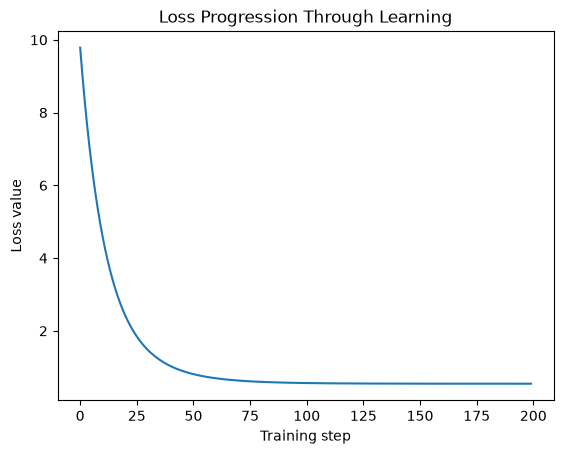

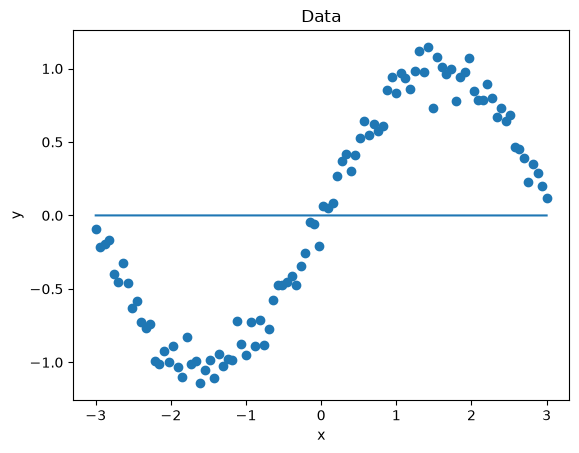

In [31]:
# TODO: Generate the toy data
# x = np.linspace(-3, 3, 100); y = np.sin(x) + small Gaussian noise (std=0.1)
#   Plot it.
np.random.seed(RANDOM_STATE)

x = np.linspace(-3, 3, 100)
y = np.sin(x) + np.random.normal(loc=0.0, scale=0.1, size=x.shape)


# TODO: Initialise w and b to small random values.
w = np.random.randn()
b = np.random.randn()
lr = 0.05

# TODO: Implement ONE gradient-descent step by hand, then loop it for ~200 steps:
#   y_hat = w * x + b
#   loss  = np.mean((y_hat - y) ** 2)               # MSE
#   dw    = np.mean(2 * (y_hat - y) * x)            # dLoss/dw  (derive this on paper!)
#   db    = np.mean(2 * (y_hat - y))                # dLoss/db
#   w    -= lr * dw
#   b    -= lr * db
#   Record the loss at every step.
losses = []

for step in range(200):
    y_hat = w * x + b
    loss = np.mean((y_hat - y) ** 2)

    dw = np.mean(2 * (y_hat - y) * x)
    db = np.mean(2 * (y_hat - y))

    w -= lr * w
    b -= lr * b

    losses.append(loss)


# TODO: Plot (a) the loss curve over the 200 steps, and
#             (b) the data with the fitted line on top.

plt.plot(losses)
plt.xlabel("Training step")
plt.ylabel("Loss value")
plt.title("Loss Progression Through Learning")
plt.show()

plt.scatter(x, y)
plt.plot(x, w * x + b)  # check to
plt.xlabel("x")
plt.ylabel("y")
plt.title("Data")
plt.show()


**Student Reasoning — The single neuron**
_1. Derive `dLoss/dw` on paper and include a photo or the LaTeX in this cell — does it match
the code?_
_2. The loss stops improving but the fit is clearly bad. Is this underfitting or overfitting,
and WHY can a single neuron never fit a sine wave, no matter how long you train?_
The fitted line is a basic horizontal line which does give a average estimate of the value in at any point in the data. This shows underfitting since the regression line shows no adaptability with the data.

> **Answer:** [Double-click to edit]


### Part 1.2 — Hidden layers and activations: why depth helps

Now build a tiny network **by hand**: 1 input -> a hidden layer of 8 neurons with `tanh` ->
1 output. Still NumPy, still manual gradients.


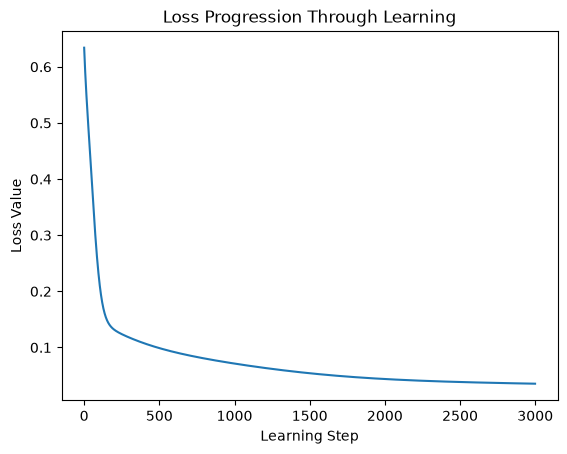

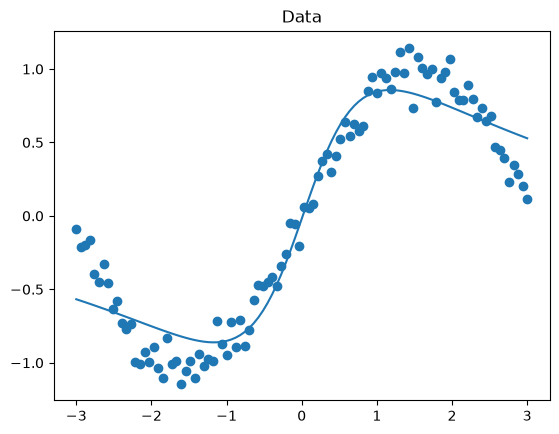

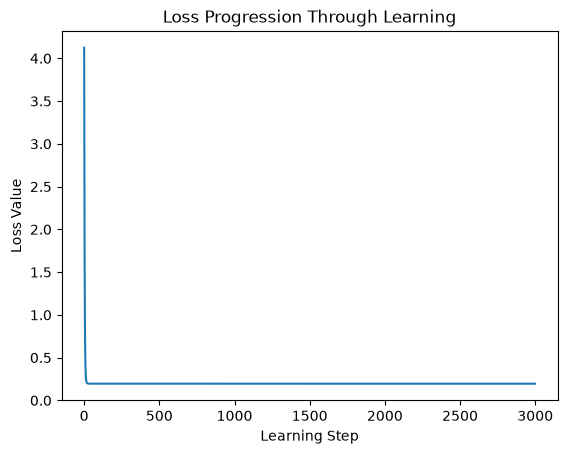

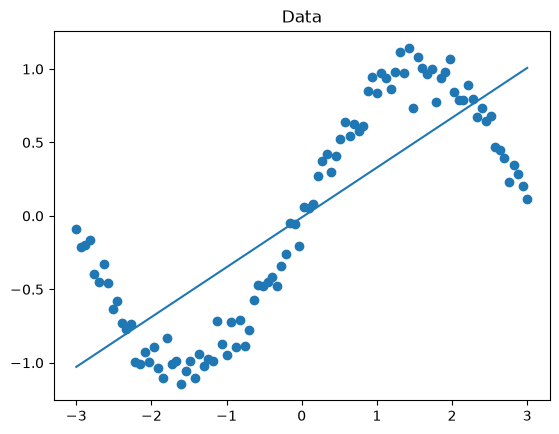

In [32]:
# TODO: Initialise parameters
np.random.seed(RANDOM_STATE)
#   W1: shape (1, 8),  b1: shape (8,)
#   W2: shape (8, 1),  b2: shape (1,)
#   Small random values (e.g. np.random.randn(...) * 0.5)
w1 = np.random.randn(1, 8) * 0.1
w2 = np.random.randn(8, 1) * 0.1
b1 = (
    np.random.randn(
        8,
    )
    * 0.1
)
b2 = (
    np.random.randn(
        1,
    )
    * 0.1
)

x = x.reshape(100, 1)
y = y.reshape(100, 1)

# TODO: Forward pass (keep the intermediate values — you need them for backprop):
#   z1 = x @ W1 + b1        # pre-activation, shape (100, 8)
#   h  = np.tanh(z1)        # activation
#   y_hat = h @ W2 + b2     # output, shape (100, 1)
#   loss  = np.mean((y_hat - y) ** 2)


# TODO: Backward pass (the chain rule, layer by layer):
#   d_yhat = 2 * (y_hat - y) / len(y)
#   dW2 = h.T @ d_yhat ;  db2 = d_yhat.sum(axis=0)
#   dh  = d_yhat @ W2.T
#   dz1 = dh * (1 - np.tanh(z1) ** 2)     # derivative of tanh
#   dW1 = x.T @ dz1 ;  db1 = dz1.sum(axis=0)

losses = []
lr = 0.01

for step in range(3000):
    # Forward pass
    z1 = x @ w1 + b1
    h = np.tanh(z1)
    y_hat = h @ w2 + b2
    loss = np.mean((y_hat - y) ** 2)

    # Backward pass
    d_yhat = 2 * (y_hat - y) / len(y)
    dw2 = h.T @ d_yhat
    db2 = d_yhat.sum(axis=0)
    dh = d_yhat @ w2.T
    dz1 = dh * (1 - np.tanh(z1) ** 2)
    dw1 = x.T @ dz1
    db1 = dz1.sum(axis=0)

    # Updated parameters
    w1 -= lr * dw1
    w2 -= lr * dw2
    b1 -= lr * db1
    b2 -= lr * db2

    # Recording losses
    losses.append(loss)

# TODO: Update all parameters with learning rate lr, loop for ~3000 steps,
#   record the loss.

# TODO: Plot the loss curve AND the final fit over the data.
plt.plot(losses)
plt.xlabel("Learning Step")
plt.ylabel("Loss Value")
plt.title("Loss Progression Through Learning")
plt.show()

plt.scatter(x, y)
plt.plot(x, y_hat)
plt.title("Data")
plt.show()

#   Then re-run with the tanh REMOVED (h = z1). What happens to the fit?
losses2 = []

for step in range(3000):
    # Forward pass
    z1 = x @ w1 + b1
    h = z1
    y_hat = h @ w2 + b2
    loss = np.mean((y_hat - y) ** 2)

    # Backward pass
    d_yhat = 2 * (y_hat - y) / len(y)
    dw2 = h.T @ d_yhat
    db2 = d_yhat.sum(axis=0)
    dh = d_yhat @ w2.T
    dz1 = dh * (1 - np.tanh(z1) ** 2)
    dw1 = x.T @ dz1
    db1 = dz1.sum(axis=0)

    # Updated parameters
    w1 -= lr * dw1
    w2 -= lr * dw2
    b1 -= lr * db1
    b2 -= lr * db2

    # Recording losses
    losses2.append(loss)

plt.plot(losses2)
plt.xlabel("Learning Step")
plt.ylabel("Loss Value")
plt.title("Loss Progression Through Learning")
plt.show()

plt.scatter(x, y)
plt.plot(x, y_hat)
plt.title("Data")
plt.show()


**Student Reasoning — Depth and activations**
_1. With tanh removed, the deep network fits no better than the single neuron of Part 1.1.
Explain mathematically why a stack of linear layers collapses into one linear layer._
_2. What role did the hidden layer's 8 neurons play in fitting the curve? (Hint: plot a few
columns of `h` against `x`.)_
_3. This is exactly what `loss.backward()` will automate in Section 2. In one sentence, what
is backpropagation?_

> **Answer:** [Double-click to edit]


### Part 1.3 — The learning rate: too cold, too hot, just right

The single most important hyperparameter. See its three regimes with your own eyes.


/Users/kojokootin/Documents/Ashesi/AshesiYear2/Sem2/AI/ai_labs/kenv2/lib/python3.14/site-packages/numpy/_core/_methods.py:132: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/var/folders/sc/xq268ph15jz0yqf4ll0nl7380000gn/T/ipykernel_81724/4109709016.py:28: RuntimeWarning: overflow encountered in square
  loss = np.mean((y_hat - y) ** 2)
/var/folders/sc/xq268ph15jz0yqf4ll0nl7380000gn/T/ipykernel_81724/4109709016.py:35: RuntimeWarning: invalid value encountered in multiply
  dz1 = dh * (1 - np.tanh(z1) ** 2)


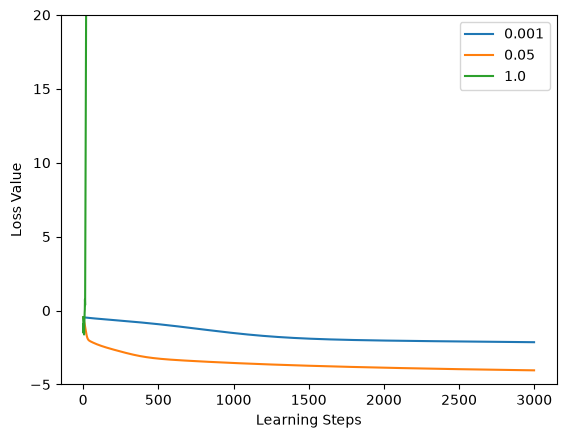

In [33]:
# TODO: Wrap your Part 1.2 training loop in a function train_toy(lr, steps=3000)
#   that returns the list of losses.


def train_toy(lr, steps=3000):
    np.random.seed(RANDOM_STATE)
    w1 = np.random.randn(1, 8) * 0.1
    w2 = np.random.randn(8, 1) * 0.1
    b1 = (
        np.random.randn(
            8,
        )
        * 0.1
    )
    b2 = (
        np.random.randn(
            1,
        )
        * 0.1
    )
    losses = []

    for step in range(3000):
        # Forward pass
        z1 = x @ w1 + b1
        h = np.tanh(z1)
        y_hat = h @ w2 + b2
        loss = np.mean((y_hat - y) ** 2)

        # Backward pass
        d_yhat = 2 * (y_hat - y) / len(y)
        dw2 = h.T @ d_yhat
        db2 = d_yhat.sum(axis=0)
        dh = d_yhat @ w2.T
        dz1 = dh * (1 - np.tanh(z1) ** 2)
        dw1 = x.T @ dz1
        db1 = dz1.sum(axis=0)

        # Updated parameters
        w1 -= lr * dw1
        w2 -= lr * dw2
        b1 -= lr * db1
        b2 -= lr * db2

        # Recording losses
        losses.append(loss)

    return losses


# TODO: Run it with THREE learning rates, e.g. lr = 0.001, 0.05, 1.0
#   (keep the same initial weights for a fair comparison — reset the seed).
model_lr1 = train_toy(0.001)
model_lr2 = train_toy(0.05)
model_lr3 = train_toy(1.0)


# TODO: Plot the three loss curves on the same axes (log scale on y helps), with a legend.
plt.plot(np.log(model_lr1), label=0.001)
plt.plot(np.log(model_lr2), label=0.05)
plt.plot(np.log(model_lr3), label=1.0)
plt.xlabel("Learning Steps")
plt.ylabel("Loss Value")
plt.ylim(-5, 20)
plt.legend()
plt.show()

**Student Reasoning — Learning rate**
_Describe what each of the three curves shows. Why does a too-large learning rate make the
loss explode or oscillate instead of just "learning faster"?_

> **Answer:** [Double-click to edit]


---

# Section 2 — A Real Feedforward Network in PyTorch

Now we let PyTorch do the bookkeeping (`autograd`, optimizers, batching) and apply the ideas
from Section 1 to a real problem — one you already know:

## Predicting obesity level (`NObeyesdad`) — the Lab 2 dataset

Same data, same 7 classes, same preprocessing ideas — but this time the model is a neural
network you design and train yourself. At the end you will compare it head-to-head with your
Lab 2 classical models.


### Part 2.1 — Preprocess and split (recycled from Lab 2)

Reuse your Lab 2 pipeline: encode categoricals, scale numerics, stratified three-way split.


In [34]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import torch

# TODO: Load the obesity dataset (same OBESITY_URL as Lab 2).
OBESITY_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"
obesity = pd.read_csv(OBESITY_URL)
# TODO: Encode categoricals exactly as you did in Lab 2
#   (binary yes/no -> 0/1; Gender/MTRANS/CAEC/CALC -> your justified choice).
#   Encode the target NObeyesdad into integers 0..6 (LabelEncoder) — CrossEntropyLoss
#   expects integer class indices.

# Clean data
obesity_cleaned = obesity.copy().dropna()

# Feature engineering: BMI
# BMI is strongly related to obesity level, so it may make the task easier.
# I include it because it is a meaningful health feature, but I discuss the fairness issue in the reasoning.
obesity_cleaned["BMI"] = obesity_cleaned["Weight"] / (obesity_cleaned["Height"] ** 2)

# Separate target from features
x_obesity_raw = obesity_cleaned.drop(columns=["NObeyesdad"]).copy()
y_obesity_raw = obesity_cleaned["NObeyesdad"].copy()

# Binary yes/no columns -> 0/1
obesity_binary_cols = ["family_history_with_overweight", "FAVC", "SMOKE", "SCC"]
yes_no_map = {"yes": 1, "no": 0, "Yes": 1, "No": 0}

for col in obesity_binary_cols:
    x_obesity_raw[col] = x_obesity_raw[col].map(yes_no_map)

# Categorical columns -> one-hot encoding
obesity_categorical_cols = ["Gender", "CAEC", "CALC", "MTRANS"]

obesity_numeric_cols = [
    "Age",
    "Height",
    "Weight",
    "FCVC",
    "NCP",
    "CH2O",
    "FAF",
    "TUE",
    "BMI",
] + obesity_binary_cols

x_obesity = pd.get_dummies(
    x_obesity_raw[obesity_numeric_cols + obesity_categorical_cols],
    columns=obesity_categorical_cols,
    drop_first=False,
)

# Encode target labels into integers
obesity_target_encoder = LabelEncoder()
y_obesity = obesity_target_encoder.fit_transform(y_obesity_raw)

# TODO: Stratified train / validation / test split (60/20/20, stratify=y,
#   random_state=RANDOM_STATE).
x_obesity_train_val, x_obesity_test, y_obesity_train_val, y_obesity_test = (
    train_test_split(
        x_obesity,
        y_obesity,
        test_size=0.20,
        random_state=RANDOM_STATE,
        stratify=y_obesity,
    )
)

x_obesity_train, x_obesity_val, y_obesity_train, y_obesity_val = train_test_split(
    x_obesity_train_val,
    y_obesity_train_val,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y_obesity_train_val,
)

# TODO: Fit a StandardScaler on the TRAINING set only; transform all three splits.
#   (Neural networks are far more sensitive to feature scale than random forests —
#    remember Section 1, where all gradients depended on x!)
obesity_scaler = StandardScaler()

x_obesity_train_scaled = x_obesity_train.copy()
x_obesity_val_scaled = x_obesity_val.copy()
x_obesity_test_scaled = x_obesity_test.copy()

x_obesity_train_scaled[obesity_numeric_cols] = obesity_scaler.fit_transform(
    x_obesity_train[obesity_numeric_cols]
)
x_obesity_val_scaled[obesity_numeric_cols] = obesity_scaler.transform(
    x_obesity_val[obesity_numeric_cols]
)
x_obesity_test_scaled[obesity_numeric_cols] = obesity_scaler.transform(
    x_obesity_test[obesity_numeric_cols]
)

# TODO: Convert to tensors and wrap in DataLoaders:
#   X -> torch.float32, y -> torch.long


x_obesity_train_tensor = torch.tensor(np.asarray(x_obesity_train_scaled, dtype = np.float32), dtype=torch.float32)
y_obesity_train_tensor = torch.tensor(y_obesity_train, dtype=torch.long)

x_obesity_test_tensor = torch.tensor(np.asarray(x_obesity_test_scaled, dtype = np.float32), dtype = torch.float32)
y_obesity_test_tensor = torch.tensor(y_obesity_test, dtype = torch.long)

x_obesity_val_tensor = torch.tensor(np.asarray(x_obesity_val_scaled, dtype = np.float32), dtype = torch.float32)
y_obesity_val_tensor = torch.tensor(y_obesity_val, dtype = torch.long)

#   train_loader (batch_size=32, shuffle=True), val_loader, test_loader
trainset = TensorDataset(x_obesity_train_tensor, y_obesity_train_tensor)
testset = TensorDataset(x_obesity_test_tensor, y_obesity_test_tensor)
valset = TensorDataset(x_obesity_val_tensor, y_obesity_val_tensor)

train_loader = DataLoader(trainset, batch_size = 32, shuffle = True)
test_loader = DataLoader(testset, batch_size = 32, shuffle = True)
val_loader = DataLoader(valset, batch_size = 32, shuffle = True)


**Student Reasoning — Preprocessing for neural networks**
_1. Why does CrossEntropyLoss need integer class labels rather than one-hot vectors in
PyTorch?_
_2. A random forest in Lab 2 did not care about feature scaling. Why do neural networks care
so much? Connect your answer to the gradient formulas you wrote in Section 1._
_3. What does `shuffle=True` on the training DataLoader do, and why does it help?_

> **Answer:** [Double-click to edit]


### Part 2.2 — Design the network

An MLP: input -> hidden layers with ReLU -> 7 output logits.


In [41]:
# TODO: Define a FeedForwardNet class (subclass nn.Module) with:
#   - constructor args: input_dim, hidden_sizes=(64, 32), n_classes=7
#   - at least TWO hidden layers with ReLU activations
#   - output layer producing 7 raw logits
#     (NO softmax — nn.CrossEntropyLoss applies log-softmax internally)

# class FeedForwardNet(nn.Module):
#     def __init__(self, ...):
#         ...
#     def forward(self, x):
#         ...
class FeedForward(nn.Module):
    def __init__(
        self,
        input_dim,
        hidden_sizes=(64, 32, 16),
        n_classes=7,
        dropout=0.0
    ):
        super().__init__()

        layers = []
        previous_size = input_dim

        for hidden_size in hidden_sizes:
            layers.append(
                nn.Linear(previous_size, hidden_size)
            )
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))

            previous_size = hidden_size

        layers.append(
            nn.Linear(previous_size, n_classes)
        )

        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)
# TODO: Instantiate, move to DEVICE, print the model.
input_dim = x_obesity_train_tensor.shape[1]
model = FeedForward(input_dim= input_dim, hidden_sizes = (64,32,16), n_classes=7).to(DEVICE)

# TODO: Count trainable parameters:
#   sum(p.numel() for p in model.parameters() if p.requires_grad)

no_parameters = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Total parameters = ", no_parameters)

#   Verify the count for the FIRST layer by hand: input_dim * 64 + 64.
first_layer_parameters = input_dim * 64 + 64
second_layer_parameters = 64 * 32 + 32
third_layer_parameters = 32 * 16 + 16
output_layer_parameters = 16 * 7 + 7

manual_total = (
    first_layer_parameters
    + second_layer_parameters
    +third_layer_parameters
    + output_layer_parameters
)

print("First layer:", first_layer_parameters)
print("Second layer:", second_layer_parameters)
print("Third layer:", third_layer_parameters)
print("Output layer:", output_layer_parameters)
print("Manual total:", manual_total)


Total parameters =  4583
First layer: 1856
Second layer: 2080
Third layer: 528
Output layer: 119
Manual total: 4583


**Student Reasoning — Architecture**
_1. Show the by-hand parameter count for every layer and confirm it matches PyTorch._
_2. Why ReLU here instead of the tanh you used in Section 1? Name one advantage._
_3. What would the network compute if you removed the ReLUs? (You proved this in Part 1.2.)_

> **Answer:** [Double-click to edit]


### Part 2.3 — The training loop

The same loop you built by hand in Section 1 — now with autograd, an optimizer, and batches.


Epoch 1/50 | Train loss: 1.9244 | Train accuracy: 0.2591 | Val loss: 1.8455 | Val accuracy: 0.3483
Epoch 2/50 | Train loss: 1.7038 | Train accuracy: 0.3997 | Val loss: 1.5094 | Val accuracy: 0.5024
Epoch 3/50 | Train loss: 1.2523 | Train accuracy: 0.5837 | Val loss: 0.9809 | Val accuracy: 0.6564
Epoch 4/50 | Train loss: 0.7986 | Train accuracy: 0.7385 | Val loss: 0.6301 | Val accuracy: 0.8365
Epoch 5/50 | Train loss: 0.5244 | Train accuracy: 0.8562 | Val loss: 0.4285 | Val accuracy: 0.9052
Epoch 6/50 | Train loss: 0.3685 | Train accuracy: 0.9100 | Val loss: 0.3234 | Val accuracy: 0.9052
Epoch 7/50 | Train loss: 0.2809 | Train accuracy: 0.9313 | Val loss: 0.2734 | Val accuracy: 0.9076
Epoch 8/50 | Train loss: 0.2250 | Train accuracy: 0.9439 | Val loss: 0.2230 | Val accuracy: 0.9408
Epoch 9/50 | Train loss: 0.1913 | Train accuracy: 0.9542 | Val loss: 0.1927 | Val accuracy: 0.9360
Epoch 10/50 | Train loss: 0.1603 | Train accuracy: 0.9613 | Val loss: 0.1918 | Val accuracy: 0.9265
Epoch 11/

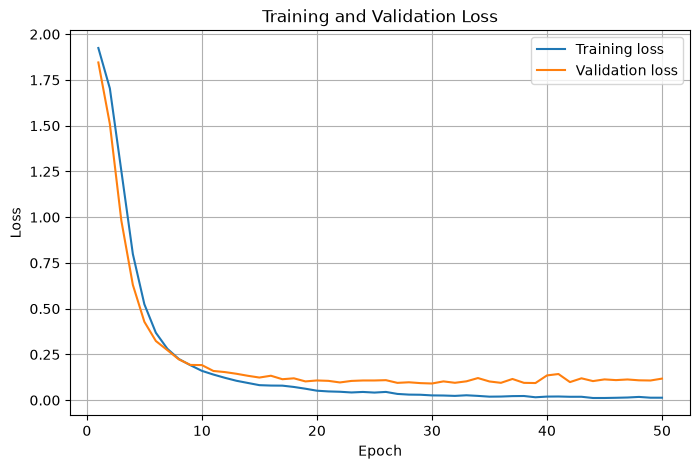

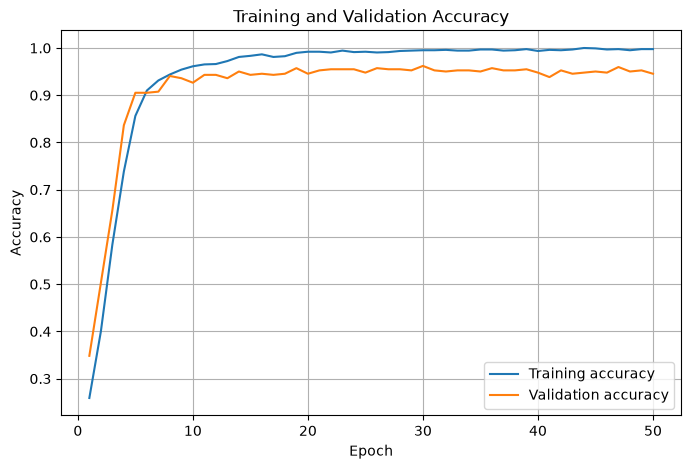

In [42]:
# TODO: criterion = nn.CrossEntropyLoss()
#       optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)   # or SGD — justify

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr = 1e-3)

# TODO: Train for at least 50 epochs. Each epoch:
#   1. model.train(); for xb, yb in train_loader:
#        optimizer.zero_grad()
#        logits = model(xb.to(DEVICE))
#        loss = criterion(logits, yb.to(DEVICE))
#        loss.backward()          # <- the backprop you wrote by hand in Part 1.2
#        optimizer.step()         # <- the update rule you wrote in Part 1.1
#   2. model.eval() + torch.no_grad(): compute loss AND accuracy on train and validation sets
#   3. Append everything to history lists; print a one-line summary per epoch.

epochs = 50

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

max_accuracy = 0.0

for epoch in range(epochs):
    #Traininig Phase
    model.train()

    train_total_loss = 0.0
    tr_correct = 0
    tr_sample = 0


    for xb, yb in train_loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)

        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        batch_size = yb.size(0)

        train_total_loss += loss.item()*batch_size
        _, prediction = torch.max(logits, 1)
        tr_correct += (prediction == yb).sum().item()

        tr_sample += batch_size

    train_loss = train_total_loss/ tr_sample
    train_accuracy = tr_correct/ tr_sample


    #Validation Phase
    model.eval()

    val_total_loss = 0.0
    val_correct = 0
    val_samples = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            logits = model(xb)
            loss = criterion(logits, yb)

            batch_size = yb.size(0)

            val_total_loss += loss.item() * batch_size

            predictions = logits.argmax(dim=1)
            val_correct += (predictions == yb).sum().item()

            val_samples += batch_size

    val_loss = val_total_loss / val_samples
    val_accuracy = val_correct / val_samples

    
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)

    # TODO: Save the best model (highest validation accuracy):
    #torch.save(model.state_dict(), "ffn_best.pt")
    if val_accuracy > max_accuracy:
        best_val_accuracy = val_accuracy
        torch.save(model.state_dict(), "ffn_best.pt")

    print(
        f"Epoch {epoch + 1}/{epochs} | "
        f"Train loss: {train_loss:.4f} | "
        f"Train accuracy: {train_accuracy:.4f} | "
        f"Val loss: {val_loss:.4f} | "
        f"Val accuracy: {val_accuracy:.4f}"
    )

# TODO: Plot loss curves (train + val) and accuracy curves (train + val), with legends.
#Loss plot
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, epochs + 1),
    train_losses,
    label="Training loss"
)

plt.plot(
    range(1, epochs + 1),
    val_losses,
    label="Validation loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

#Accuracy plot
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, epochs + 1),
    train_accuracies,
    label="Training accuracy"
)

plt.plot(
    range(1, epochs + 1),
    val_accuracies,
    label="Validation accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

**Student Reasoning — Training**
_1. Map each line of the PyTorch loop to the NumPy code you wrote in Section 1: which line is
the forward pass, which computes gradients, which is the update rule?_
_2. Looking at your curves, is the model overfitting, underfitting, or well-fitted? Quote the
specific numbers that back up your claim._
_3. Why do we call `optimizer.zero_grad()` every batch? What silently goes wrong without it?_

> **Answer:** [Double-click to edit]


### Part 2.4 — Experiments: how training choices change the outcome

Run **three controlled experiments**. Change ONE thing at a time; keep everything else fixed.


Epoch 1/50 | Train loss: 1.9547 | Train accuracy: 0.1137 | Val loss: 1.9240 | Val accuracy: 0.1327
Epoch 2/50 | Train loss: 1.8859 | Train accuracy: 0.1430 | Val loss: 1.8473 | Val accuracy: 0.2275
Epoch 3/50 | Train loss: 1.7902 | Train accuracy: 0.3357 | Val loss: 1.7333 | Val accuracy: 0.4336
Epoch 4/50 | Train loss: 1.6704 | Train accuracy: 0.4502 | Val loss: 1.6071 | Val accuracy: 0.4692
Epoch 5/50 | Train loss: 1.5485 | Train accuracy: 0.4850 | Val loss: 1.4847 | Val accuracy: 0.4929
Epoch 6/50 | Train loss: 1.4276 | Train accuracy: 0.5482 | Val loss: 1.3659 | Val accuracy: 0.5450
Epoch 7/50 | Train loss: 1.3137 | Train accuracy: 0.5940 | Val loss: 1.2599 | Val accuracy: 0.5711
Epoch 8/50 | Train loss: 1.2143 | Train accuracy: 0.6074 | Val loss: 1.1691 | Val accuracy: 0.5877
Epoch 9/50 | Train loss: 1.1306 | Train accuracy: 0.6201 | Val loss: 1.0945 | Val accuracy: 0.6090
Epoch 10/50 | Train loss: 1.0613 | Train accuracy: 0.6303 | Val loss: 1.0324 | Val accuracy: 0.6374
Epoch 11/

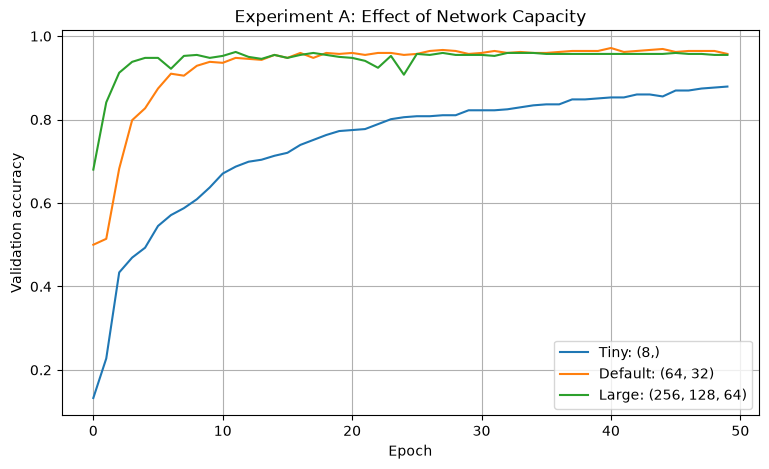

Epoch 1/50 | Train loss: 1.9425 | Train accuracy: 0.1517 | Val loss: 1.9355 | Val accuracy: 0.2038
Epoch 2/50 | Train loss: 1.9289 | Train accuracy: 0.2457 | Val loss: 1.9222 | Val accuracy: 0.2749
Epoch 3/50 | Train loss: 1.9141 | Train accuracy: 0.2946 | Val loss: 1.9067 | Val accuracy: 0.2938
Epoch 4/50 | Train loss: 1.8965 | Train accuracy: 0.3057 | Val loss: 1.8884 | Val accuracy: 0.2986
Epoch 5/50 | Train loss: 1.8754 | Train accuracy: 0.3207 | Val loss: 1.8659 | Val accuracy: 0.3104
Epoch 6/50 | Train loss: 1.8502 | Train accuracy: 0.3428 | Val loss: 1.8392 | Val accuracy: 0.3483
Epoch 7/50 | Train loss: 1.8208 | Train accuracy: 0.3965 | Val loss: 1.8067 | Val accuracy: 0.4171
Epoch 8/50 | Train loss: 1.7855 | Train accuracy: 0.4558 | Val loss: 1.7689 | Val accuracy: 0.4787
Epoch 9/50 | Train loss: 1.7440 | Train accuracy: 0.5245 | Val loss: 1.7247 | Val accuracy: 0.5261
Epoch 10/50 | Train loss: 1.6952 | Train accuracy: 0.5458 | Val loss: 1.6728 | Val accuracy: 0.5308
Epoch 11/

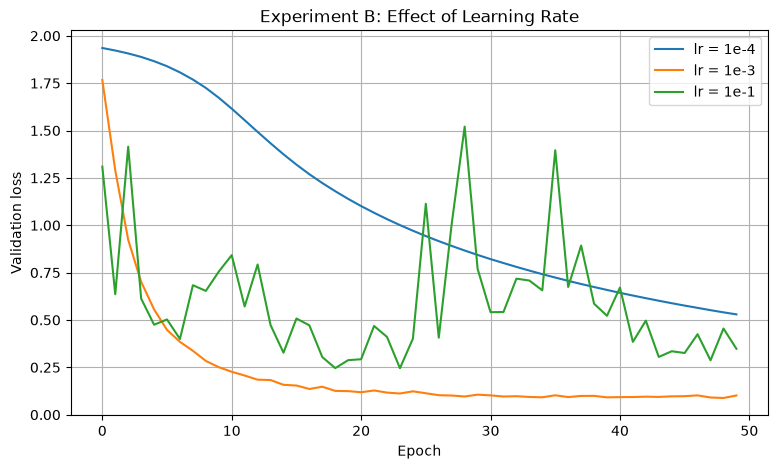

Epoch 1/50 | Train loss: 1.5712 | Train accuracy: 0.4581 | Val loss: 0.9898 | Val accuracy: 0.6801
Epoch 2/50 | Train loss: 0.6655 | Train accuracy: 0.7796 | Val loss: 0.4565 | Val accuracy: 0.8412
Epoch 3/50 | Train loss: 0.3386 | Train accuracy: 0.8942 | Val loss: 0.2641 | Val accuracy: 0.9123
Epoch 4/50 | Train loss: 0.2261 | Train accuracy: 0.9329 | Val loss: 0.1934 | Val accuracy: 0.9384
Epoch 5/50 | Train loss: 0.1457 | Train accuracy: 0.9621 | Val loss: 0.1556 | Val accuracy: 0.9479
Epoch 6/50 | Train loss: 0.0964 | Train accuracy: 0.9842 | Val loss: 0.1374 | Val accuracy: 0.9479
Epoch 7/50 | Train loss: 0.0874 | Train accuracy: 0.9826 | Val loss: 0.2015 | Val accuracy: 0.9218
Epoch 8/50 | Train loss: 0.0800 | Train accuracy: 0.9787 | Val loss: 0.1283 | Val accuracy: 0.9526
Epoch 9/50 | Train loss: 0.0482 | Train accuracy: 0.9889 | Val loss: 0.1305 | Val accuracy: 0.9550
Epoch 10/50 | Train loss: 0.0481 | Train accuracy: 0.9905 | Val loss: 0.1672 | Val accuracy: 0.9479
Epoch 11/

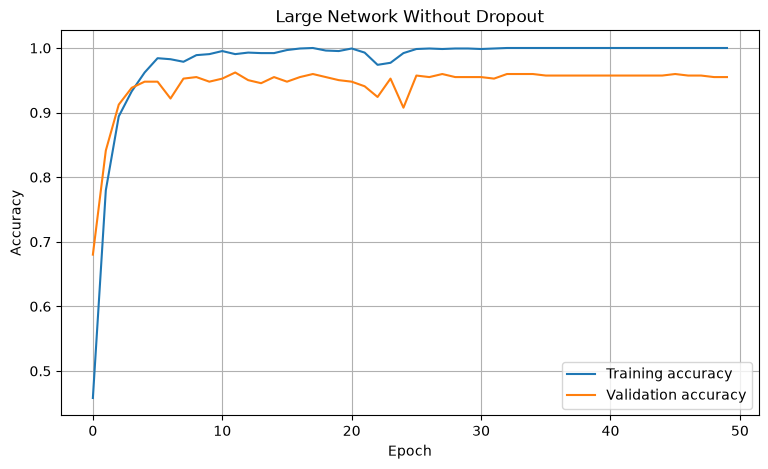

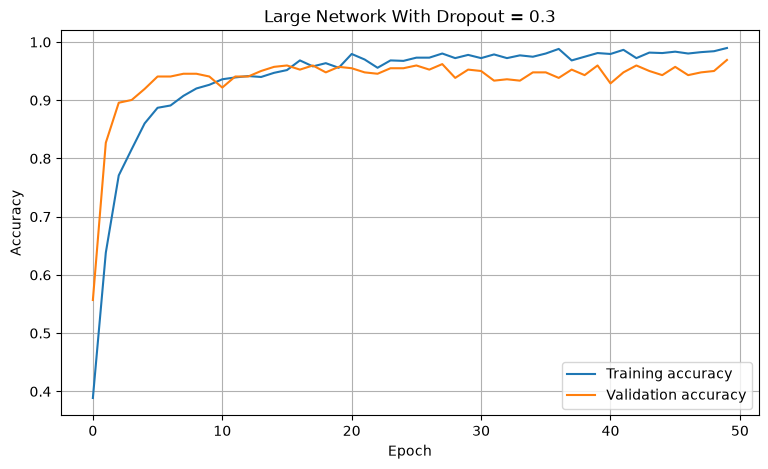

In [46]:
# Wrap your Part 2.3 loop in a function first:
#   def run_experiment(hidden_sizes=(64, 32), lr=1e-3, batch_size=32, epochs=50, dropout=0.0):
#       ... returns history dict ...

def run_experiment(hidden_sizes=(64, 32, 16), lr=1e-3, batch_size=32, epochs=50, dropout=0.0):
    torch.manual_seed(RANDOM_STATE)
    np.random.seed(RANDOM_STATE)

    experiment_train_loader = DataLoader(trainset, batch_size=batch_size,shuffle=True)
    experiment_val_loader = DataLoader(valset,batch_size=batch_size,shuffle=False)
    experiment_model = FeedForward(input_dim=input_dim,hidden_sizes=hidden_sizes,n_classes=7,dropout=dropout).to(DEVICE)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(experiment_model.parameters(), lr=lr)

    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []

    max_accuracy = 0.0
    best_model_state = None

    for epoch in range(epochs):
        #Traininig Phase
        experiment_model.train()

        train_total_loss = 0.0
        tr_correct = 0
        tr_sample = 0


        for xb, yb in experiment_train_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            optimizer.zero_grad()
            logits = experiment_model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

            current_batch_size = yb.size(0)

            train_total_loss += loss.item()*current_batch_size
            _, prediction = torch.max(logits, 1)
            tr_correct += (prediction == yb).sum().item()

            tr_sample += current_batch_size

        train_loss = train_total_loss/ tr_sample
        train_accuracy = tr_correct/ tr_sample


        #Validation Phase
        experiment_model.eval()

        val_total_loss = 0.0
        val_correct = 0
        val_samples = 0
        with torch.no_grad():
            for xb, yb in experiment_val_loader:
                xb = xb.to(DEVICE)
                yb = yb.to(DEVICE)

                logits = experiment_model(xb)
                loss = criterion(logits, yb)

                current_batch_size = yb.size(0)

                val_total_loss += loss.item() * current_batch_size

                predictions = logits.argmax(dim=1)
                val_correct += (predictions == yb).sum().item()

                val_samples += current_batch_size

        val_loss = val_total_loss / val_samples
        val_accuracy = val_correct / val_samples

        
        train_losses.append(train_loss)
        val_losses.append(val_loss)

        train_accuracies.append(train_accuracy)
        val_accuracies.append(val_accuracy)

        # TODO: Save the best model (highest validation accuracy):
        #torch.save(model.state_dict(), "ffn_best.pt")
        if val_accuracy > max_accuracy:
            max_accuracy = val_accuracy

            best_model_state = {
                name: parameter.detach().cpu().clone()
                for name, parameter
                in experiment_model.state_dict().items()
            }

        print(
            f"Epoch {epoch + 1}/{epochs} | "
            f"Train loss: {train_loss:.4f} | "
            f"Train accuracy: {train_accuracy:.4f} | "
            f"Val loss: {val_loss:.4f} | "
            f"Val accuracy: {val_accuracy:.4f}"
        )
    history = {
        "train_losses": train_losses,
        "val_losses": val_losses,
        "train_accuracies": train_accuracies,
        "val_accuracies": val_accuracies,
        "best_val_accuracy": max_accuracy,
        "best_model_state": best_model_state,
        "model": experiment_model
    }

    return history

        
    


# TODO — Experiment A (capacity): tiny (8,) vs default (64, 32) vs large (256, 128, 64).
#   Plot the three validation-accuracy curves together.
tiny_result = run_experiment(
    hidden_sizes=(8,),
    lr=1e-3,
    batch_size=32,
    epochs=50,
    dropout=0.0
)

default_result = run_experiment(
    hidden_sizes=(64, 32),
    lr=1e-3,
    batch_size=32,
    epochs=50,
    dropout=0.0
)

large_result = run_experiment(
    hidden_sizes=(256, 128, 64),
    lr=1e-3,
    batch_size=32,
    epochs=50,
    dropout=0.0
)
plt.figure(figsize=(9, 5))

plt.plot(
    tiny_result["val_accuracies"],
    label="Tiny: (8,)"
)

plt.plot(
    default_result["val_accuracies"],
    label="Default: (64, 32)"
)

plt.plot(
    large_result["val_accuracies"],
    label="Large: (256, 128, 64)"
)

plt.xlabel("Epoch")
plt.ylabel("Validation accuracy")
plt.title("Experiment A: Effect of Network Capacity")
plt.legend()
plt.grid()
plt.show()

# TODO — Experiment B (learning rate): lr = 1e-4, 1e-3, 1e-1 (same architecture).
#   Plot the three validation-loss curves together. Compare with Part 1.3.

small_lr_result = run_experiment(
    hidden_sizes=(64, 32),
    lr=1e-4,
    batch_size=32,
    epochs=50,
    dropout=0.0
)

medium_lr_result = run_experiment(
    hidden_sizes=(64, 32),
    lr=1e-3,
    batch_size=32,
    epochs=50,
    dropout=0.0
)

large_lr_result = run_experiment(
    hidden_sizes=(64, 32),
    lr=1e-1,
    batch_size=32,
    epochs=50,
    dropout=0.0
)

plt.figure(figsize=(9, 5))

plt.plot(
    small_lr_result["val_losses"],
    label="lr = 1e-4"
)

plt.plot(
    medium_lr_result["val_losses"],
    label="lr = 1e-3"
)

plt.plot(
    large_lr_result["val_losses"],
    label="lr = 1e-1"
)

plt.xlabel("Epoch")
plt.ylabel("Validation loss")
plt.title("Experiment B: Effect of Learning Rate")
plt.legend()
plt.grid()
plt.show()

# TODO — Experiment C (regularization): take your LARGEST network and train it
#   with and without nn.Dropout(0.3) after each hidden layer.
#   Plot train vs validation accuracy for both runs.
large_no_dropout = run_experiment(hidden_sizes=(256, 128, 64),lr=1e-3, batch_size=32,epochs=50, dropout=0.0)
large_with_dropout = run_experiment(hidden_sizes=(256, 128, 64),lr=1e-3,batch_size=32,epochs=50,dropout=0.2)

#Without Dropout
plt.figure(figsize=(9, 5))

plt.plot(
    large_no_dropout["train_accuracies"],
    label="Training accuracy"
)

plt.plot(
    large_no_dropout["val_accuracies"],
    label="Validation accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Large Network Without Dropout")
plt.legend()
plt.grid()
plt.show()

#With dropout
plt.figure(figsize=(9, 5))

plt.plot(
    large_with_dropout["train_accuracies"],
    label="Training accuracy"
)

plt.plot(
    large_with_dropout["val_accuracies"],
    label="Validation accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Large Network With Dropout = 0.3")
plt.legend()
plt.grid()
plt.show()

**Student Reasoning — Experiments**
_1. Capacity: did the largest network win on validation data? Where do you see diminishing
returns or overfitting?_
_2. Learning rate: do the three regimes match what you saw on the toy problem in Part 1.3?_
_3. Regularization: what did dropout do to the train-vs-validation gap? Explain in one or two
sentences HOW dropout achieves this._

> **Answer:** [Double-click to edit]


### Part 2.5 — Final evaluation and showdown with Lab 2

One honest number on the test set — then compare with your classical models.


In [ ]:
# TODO: Load your best configuration's weights; model.eval().


# TODO: Report test ACCURACY and MACRO-F1
#   from sklearn.metrics import accuracy_score, f1_score, classification_report

# TODO: Confusion matrix for the test set with the 7 class names
#   from sklearn.metrics import ConfusionMatrixDisplay

# TODO: Build a small comparison table (a pandas DataFrame is fine):
#   rows = [your best Lab 2 classifier, this neural network]
#   cols = [test accuracy, test macro-F1, training time, number of parameters/trees]

**Student Reasoning — Final evaluation**
_1. Which obesity levels does the network still confuse, and are they the same ones your
Lab 2 classifier confused?_
_2. Who wins the showdown — the neural network or the classical model? Was the extra effort
of deep learning worth it on THIS dataset? When would it be?_

> **Answer:** [Double-click to edit]


---

# Section 3 — Reflection

_Answer in a few sentences each:_

1. **The black box, opened:** Name the three most important things happening inside
   `loss.backward()` and `optimizer.step()`, in your own words.
2. **Hyperparameters:** If you could tune only ONE hyperparameter on a new problem, which
   would you pick and why?
3. **Overfitting:** Across your experiments, where did you see the biggest
   train-vs-validation gap, and which intervention reduced it most?
4. **Looking ahead:** This network treats every input feature independently. Next lab we move
   to images, where nearby pixels are related. Why might a plain MLP struggle with images,
   and what property should a better architecture have?

> **Answer:** [Double-click to edit]


---

### Submission checklist

- [ ] All cells run top-to-bottom with no errors (`Kernel -> Restart & Run All`).
- [ ] Every **Student Reasoning** box is filled in with full sentences.
- [ ] Plots are visible in the saved notebook (loss curves, fits, experiments, confusion matrix).
- [ ] Notebook committed and pushed to your `lab-3-feedforward-networks` repository, with
      incremental commits (not one final dump).
- [ ] Repository link submitted to the course portal.
- [ ] AI Declaration form in Repository.
